Loaded 99 episodes.
Target resample length: 293
Valid clusters (excluding noise): [0, 1, 2, 3, 4]
Cluster 0: size=6, entropy=-64026.4796, score=6739.6294
Cluster 1: size=12, entropy=-12795.0205, score=2693.6885
Cluster 2: size=20, entropy=-46620.8808, score=16358.2038
Cluster 3: size=14, entropy=-12783.6689, score=3139.8485
Cluster 4: size=5, entropy=-67869.6195, score=5953.4754
Identified expert clusters: [0, 2, 4]


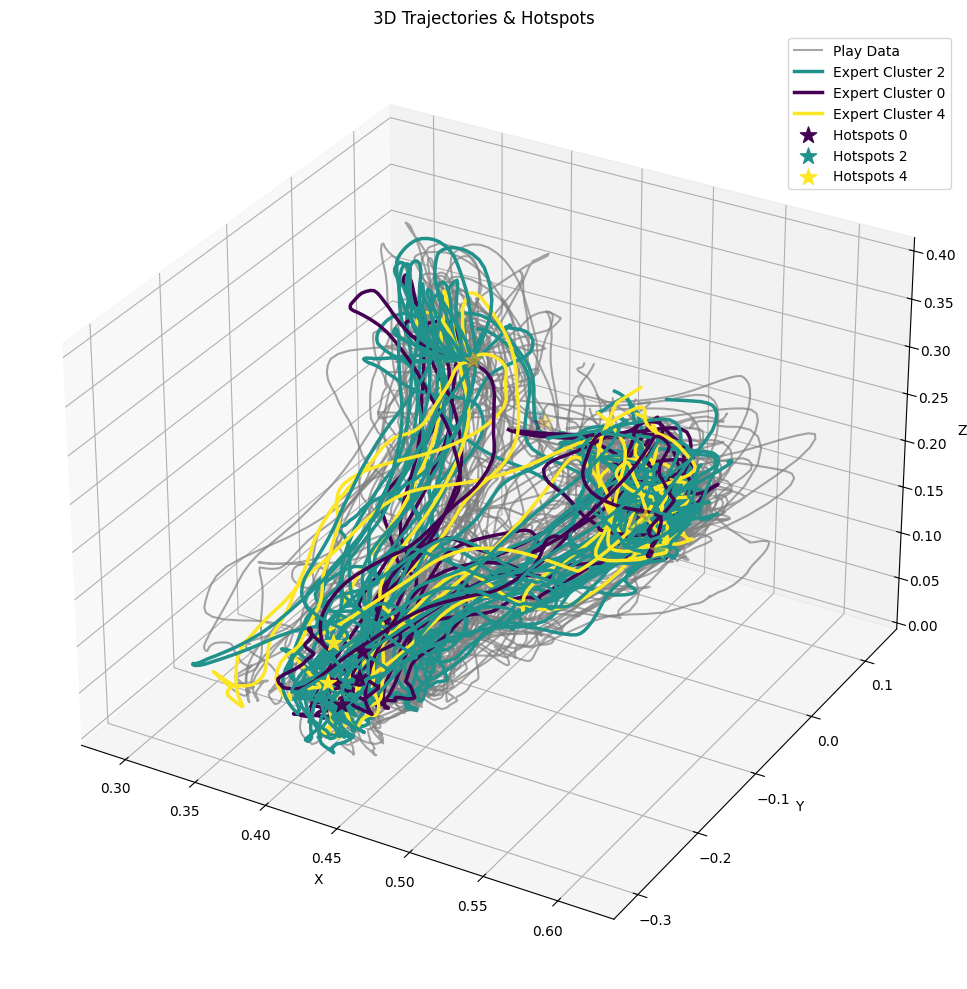

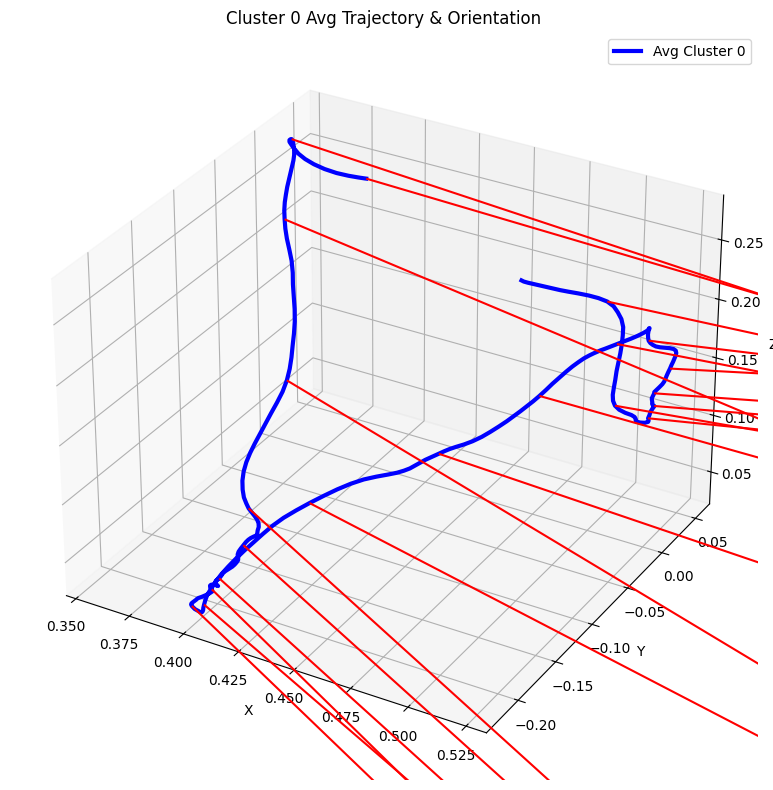

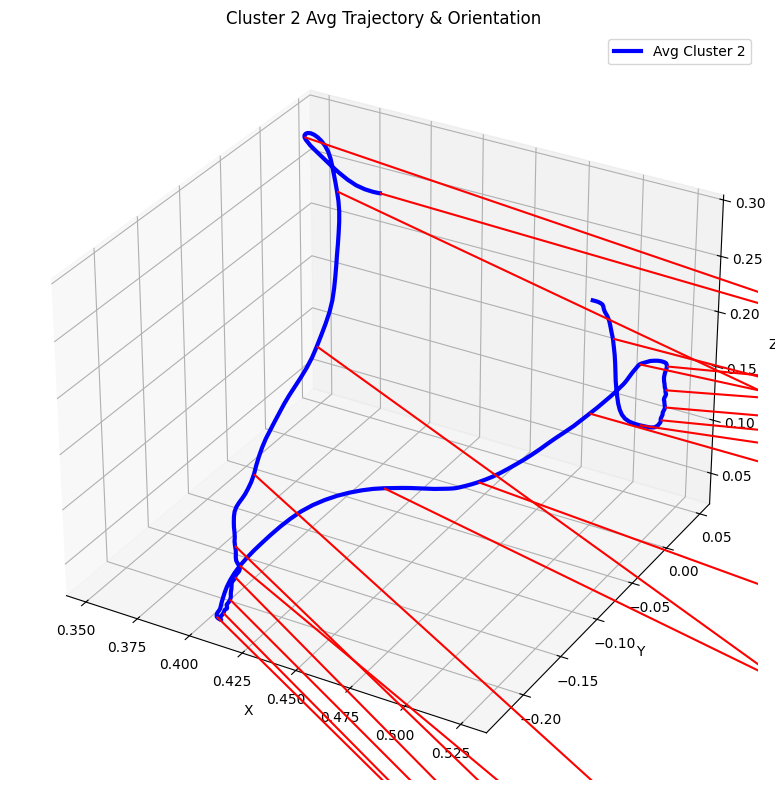

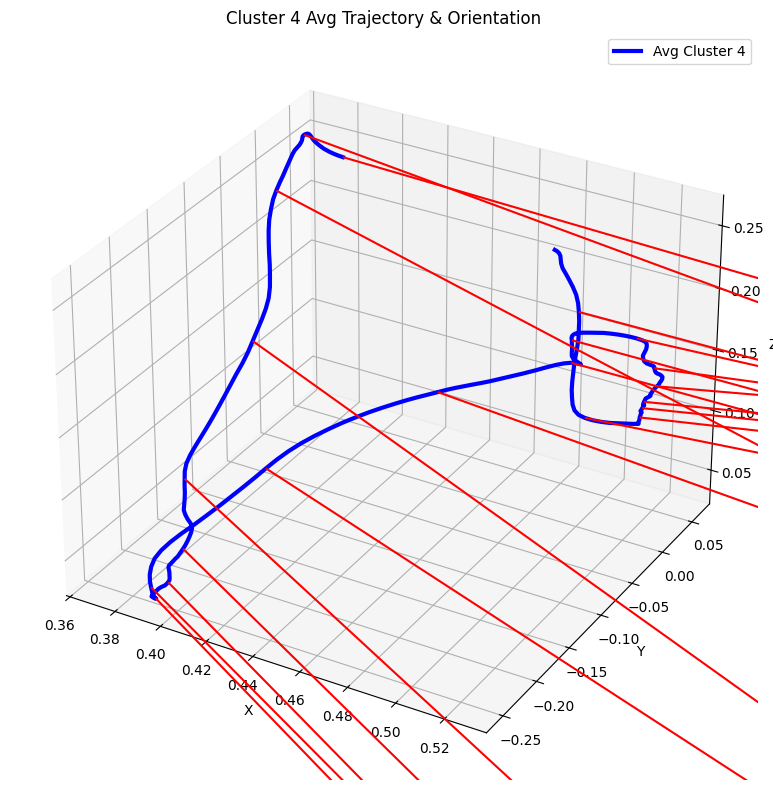

In [2]:
#!/usr/bin/env python3
"""
Cluster trajectories from a local LeRobot dataset using scikit-learn’s HDBSCAN.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
from sklearn.cluster import MeanShift, estimate_bandwidth, HDBSCAN
from scipy.spatial.transform import Rotation as R  # For quaternion operations
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
from collections import defaultdict
import h5py

# =============================================================================
# 1. Load full trajectories from a LeRobot dataset
# =============================================================================
def load_trajectories(dataset_path: str):
    """
    Loads complete trajectories from the given LeRobot dataset.
    Each demonstration episode is reconstructed by grouping frames with the same episode_index.
    
    Args:
        dataset_path: Root folder of your LeRobot dataset (contains meta/, data/, videos/).
        
    Returns:
        List of np.arrays, each of shape (n_steps, state_dim).
    """
    ds = LeRobotDataset(repo_id="local", root=dataset_path)
    hf = ds.hf_dataset 

    groups = defaultdict(list)
    for sample in hf:
        ep = int(sample["episode_index"])
        state = sample["observation.state"]
        try:
            state = state.cpu().numpy()
        except AttributeError:
            pass
        groups[ep].append(state)
        # now we have a map from trajectory or episode index to the data

    return [np.vstack(frames) for frames in groups.values()]
    # return list of arrays, each shape (n_steps, state_dim)
    # Note: this is a list of arrays, not a single array.

def load_trajectories_hdf5(dataset_path : str):
    trajectories, demo_names = [], []
    with h5py.File(dataset_path, 'r') as hdf:
        for key in hdf['data']:
            grp = hdf['data'][key]
            if 'obs' in grp and 'states' in grp['obs']:
                traj = grp['obs']['states'][:]
                if traj.shape[0] > 0:
                    trajectories.append(traj)
                    demo_names.append(key)
    return trajectories, demo_names


# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length):
    orig, dim = traj.shape
    old_idx = np.arange(orig)
    new_idx = np.linspace(0, orig - 1, new_length)
    out = np.zeros((new_length, dim), dtype=traj.dtype)
    for d in range(dim):
        out[:, d] = np.interp(new_idx, old_idx, traj[:, d])
    return out

# =============================================================================
# 4. Feature extraction for a single trajectory
# =============================================================================
def extract_features(traj):
    return traj.flatten()

# =============================================================================
# 5. Compute differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    return 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)

# =============================================================================
# 6. Extract hotspots via MeanShift
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bw = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: clustering, expert identification, hotspot extraction, plotting
# =============================================================================
def main():
    dataset_path = "/home/marco/Roboviz/data/one_leg_expert_h1_rosario_L0_lowinsertforce_relative_continuous.hdf5"
    
    # Load & group trajectories
    if dataset_path.split('.')[-1] == "hdf5":
        trajectories, _ = load_trajectories_hdf5(dataset_path)
    else:
        trajectories = load_trajectories(dataset_path)
    print(f"Loaded {len(trajectories)} episodes.")
    
    # Resample to median length
    target_len = choose_resample_length(trajectories)
    print("Target resample length:", target_len)
    trajs_res = [resample_trajectory(t, target_len) for t in trajectories]
    
    # Build feature matrix
    feats = np.vstack([extract_features(t) for t in trajs_res])
    
    # Use sklearn's HDBSCAN for clustering
    clusterer = HDBSCAN(min_cluster_size=5, min_samples=2)
    labels = clusterer.fit_predict(feats)
    unique = np.unique(labels)
    valid = [l for l in unique if l != -1]
    print("Valid clusters (excluding noise):", valid)
    
    # Score clusters
    entropies = {l: compute_cluster_entropy(feats[labels==l]) for l in valid}
    sizes     = {l: np.sum(labels==l) for l in valid}
    total     = sum(sizes.values())
    scores    = {l: (-entropies[l]) * (sizes[l]/total) for l in valid}
    for l in valid:
        print(f"Cluster {l}: size={sizes[l]}, entropy={entropies[l]:.4f}, score={scores[l]:.4f}")
    thresh  = np.median(list(scores.values())) if scores else 0
    experts = [l for l, s in scores.items() if s >= thresh]
    print("Identified expert clusters:", experts)
    
    # Extract hotspots
    hotspots = {}
    for l in experts:
        pts = np.vstack([t for t, lab in zip(trajs_res, labels) if lab == l])
        hotspots[l] = extract_hotspots(pts)
    
    # -------------------------------------------------------------------------
    # Plot trajectories & hotspots with expert lines on top of play data
    # -------------------------------------------------------------------------
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection='3d')
    cmap = plt.get_cmap('viridis', len(valid) or 1)
    idx_map = {l:i for i,l in enumerate(valid)}

    # 1) Plot all Play data first
    played_legend = False
    for traj, lab in zip(trajs_res, labels):
        if lab == -1 or lab not in experts:
            if not played_legend:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color='gray', lw=1.5, alpha=0.7,
                        label="Play Data")
                played_legend = True
            else:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color='gray', lw=1.5, alpha=0.7)

    # 2) Then plot Expert clusters on top
    seen = set()
    for traj, lab in zip(trajs_res, labels):
        if lab in experts:
            color = cmap(idx_map[lab])
            lw    = 2.5
            tag   = f"Expert Cluster {lab}"
            if tag not in seen:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color=color, lw=lw, label=tag)
                seen.add(tag)
            else:
                ax.plot(traj[:,0], traj[:,1], traj[:,2],
                        color=color, lw=lw)

    # 3) Finally, draw the hotspots
    for l, ctr in hotspots.items():
        if ctr.size:
            ax.scatter(ctr[:,0], ctr[:,1], ctr[:,2],
                       s=150, marker='*',
                       color=cmap(idx_map[l]),
                       label=f"Hotspots {l}")

    ax.set(title="3D Trajectories & Hotspots",
           xlabel="X", ylabel="Y", zlabel="Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # -------------------------------------------------------------------------
    # Plot per-expert average trajectory & orientation
    # -------------------------------------------------------------------------
    state_dim = trajs_res[0].shape[1]
    for l in experts:
        cluster_trajs = [traj for traj, lab in zip(trajs_res, labels) if lab == l]
        arr = np.stack(cluster_trajs, axis=0)
        avg = arr.mean(axis=0)
        
        # If quaternion available, compute average direction
        if state_dim >= 7:
            T = avg.shape[0]
            dirs = np.zeros((T,3))
            for i in range(T):
                quats = arr[:,i,3:7]
                dirs[i] = R.from_quat(quats).mean().apply([1,0,0])
        else:
            dirs = None
        
        fig2 = plt.figure(figsize=(10,8))
        ax2  = fig2.add_subplot(111, projection='3d')
        ax2.plot(avg[:,0], avg[:,1], avg[:,2], 'b-', lw=3, label=f"Avg Cluster {l}")
        
        if dirs is not None:
            step = max(1, T//20)
            for i in range(0, T, step):
                x,y,z = avg[i,:3]
                dx,dy,dz = dirs[i]
                ax2.quiver(x,y,z,dx,dy,dz, length=0.5, normalize=True, color='r')
        
        ax2.set(title=f"Cluster {l} Avg Trajectory & Orientation",
                xlabel="X", ylabel="Y", zlabel="Z")
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()